In [1]:
# 1. Imports
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
RANDOM_STATE = 42


In [2]:
# 2. Locate and load the competition data
search_roots = ["/kaggle/input", "."]

def find_file(filename):
    for root in search_roots:
        matches = glob.glob(os.path.join(root, "**", filename), recursive=True)
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Could not find {filename} under {search_roots}")

train_path = find_file("train.csv")
test_path = find_file("test.csv")
sample_sub_path = find_file("sample_submission.csv")

print("train:", train_path)
print("test:", test_path)
print("sample_submission:", sample_sub_path)

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_sub.shape)
train_df.head()


train: /kaggle/input/competitions/co5420-human-activity-recognition/train.csv
test: /kaggle/input/competitions/co5420-human-activity-recognition/co5420-human-activity-recognition/test.csv
sample_submission: /kaggle/input/competitions/co5420-human-activity-recognition/sample_submission.csv

Train shape: (7352, 563)
Test shape: (2947, 563)
Sample submission shape: (2947, 2)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-sma(),tBodyAcc-energy()-X,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tBodyAcc-iqr()-X,tBodyAcc-iqr()-Y,tBodyAcc-iqr()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,...,fBodyBodyGyroMag-meanFreq(),fBodyBodyGyroMag-skewness(),fBodyBodyGyroMag-kurtosis(),fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-std(),fBodyBodyGyroJerkMag-mad(),fBodyBodyGyroJerkMag-max(),fBodyBodyGyroJerkMag-min(),fBodyBodyGyroJerkMag-sma(),fBodyBodyGyroJerkMag-energy(),fBodyBodyGyroJerkMag-iqr(),fBodyBodyGyroJerkMag-entropy(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,-0.567378,-0.744413,0.852947,0.685845,0.814263,-0.965523,-0.999945,-0.999863,-0.994612,-0.994231,-0.987614,-0.943220,-0.407747,-0.679338,-0.602122,...,-0.128989,0.586156,0.374605,-0.991990,-0.990697,-0.989941,-0.992448,-0.991048,-0.991990,-0.999937,-0.990458,-0.871306,-1.000000,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,-0.557851,-0.818409,0.849308,0.685845,0.822637,-0.981930,-0.999991,-0.999788,-0.998405,-0.999150,-0.977866,-0.948225,-0.714892,-0.500930,-0.570979,...,-0.271958,-0.336310,-0.720015,-0.995854,-0.996399,-0.995442,-0.996866,-0.994440,-0.995854,-0.999981,-0.994544,-1.000000,-1.000000,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,-0.557851,-0.818409,0.843609,0.682401,0.839344,-0.983478,-0.999969,-0.999660,-0.999470,-0.997130,-0.964810,-0.974675,-0.592235,-0.485821,-0.570979,...,-0.212728,-0.535352,-0.871914,-0.995031,-0.995127,-0.994640,-0.996060,-0.995866,-0.995031,-0.999973,-0.993755,-1.000000,-0.555556,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,-0.576159,-0.829711,0.843609,0.682401,0.837869,-0.986093,-0.999976,-0.999736,-0.999504,-0.997180,-0.983799,-0.986007,-0.627446,-0.850930,-0.911872,...,-0.035684,-0.230091,-0.511217,-0.995221,-0.995237,-0.995722,-0.995273,-0.995732,-0.995221,-0.999974,-0.995226,-0.955696,-0.936508,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,-0.569174,-0.824705,0.849095,0.683250,0.837869,-0.992653,-0.999991,-0.999856,-0.999757,-0.998004,-0.981232,-0.991325,-0.786553,-0.559477,-0.761434,...,-0.273582,-0.510282,-0.830702,-0.995093,-0.995465,-0.995279,-0.995609,-0.997418,-0.995093,-0.999974,-0.995487,-1.000000,-0.936508,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [3]:
# Identify the target column and (if present) an id column automatically,
CANDIDATE_TARGETS = ["Activity", "activity", "label", "Label", "target", "Target", "Activity_Label"]
CANDIDATE_IDS = ["Id", "id", "ID", "subject", "Subject", "index"]

target_col = next((c for c in CANDIDATE_TARGETS if c in train_df.columns), None)
if target_col is None:
    # fall back: last non-numeric column is almost certainly the label
    non_numeric = train_df.select_dtypes(exclude=[np.number]).columns.tolist()
    target_col = non_numeric[-1] if non_numeric else train_df.columns[-1]

id_col = next((c for c in CANDIDATE_IDS if c in test_df.columns), None)

print("Detected target column:", target_col)
print("Detected id column in test set:", id_col)

print("\nClass distribution:")
print(train_df[target_col].value_counts())


Detected target column: Activity
Detected id column in test set: id

Class distribution:
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


/tmp/ipykernel_16/1108029789.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df[target_col], order=train_df[target_col].value_counts().index, palette="viridis")


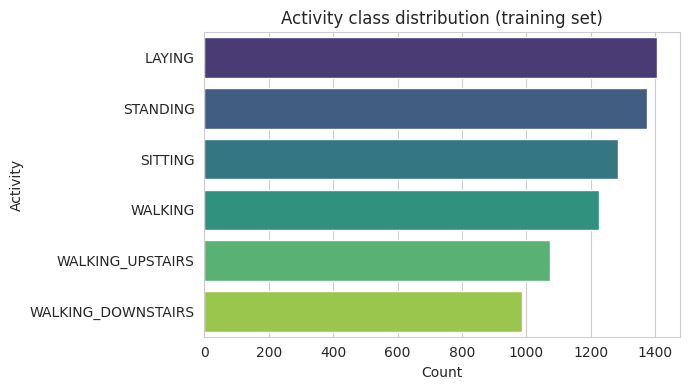

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(y=train_df[target_col], order=train_df[target_col].value_counts().index, palette="viridis")
plt.title("Activity class distribution (training set)")
plt.xlabel("Count")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()


In [5]:
feature_cols = [c for c in train_df.columns if c not in [target_col, id_col]]
feature_cols = [c for c in feature_cols if c in test_df.columns]  # keep only columns shared with test set

X = train_df[feature_cols].copy()
y_raw = train_df[target_col].copy()

X_kaggle_test = test_df[feature_cols].copy()

# Encode the activity labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
print("Classes:", list(label_encoder.classes_))

# Train / validation split (stratified to preserve class balance)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Feature scaling (fit on training data only, then applied everywhere)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_kaggle_test_scaled = scaler.transform(X_kaggle_test)

print("Train:", X_train_scaled.shape, " Val:", X_val_scaled.shape, " Kaggle test:", X_kaggle_test_scaled.shape)


Classes: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
Train: (5881, 562)  Val: (1471, 562)  Kaggle test: (2947, 562)


In [6]:
svm_baseline = SVC(kernel="rbf", random_state=RANDOM_STATE)
svm_baseline.fit(X_train_scaled, y_train)

svm_baseline_pred = svm_baseline.predict(X_val_scaled)
print("Baseline SVM (RBF kernel) validation accuracy:", accuracy_score(y_val, svm_baseline_pred))


Baseline SVM (RBF kernel) validation accuracy: 0.9796057104010877


In [7]:
# Hyperparameter tuning for SVM (kernel, C, gamma)
svm_param_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", 0.01, 0.001]},
    {"kernel": ["poly"], "C": [0.1, 1, 10], "degree": [2, 3], "gamma": ["scale"]},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_grid = GridSearchCV(
    SVC(random_state=RANDOM_STATE),
    param_grid=svm_param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)
svm_grid.fit(X_train_scaled, y_train)

print("Best SVM params:", svm_grid.best_params_)
print("Best CV F1 (weighted):", svm_grid.best_score_)

svm_best = svm_grid.best_estimator_


Fitting 5 folds for each of 21 candidates, totalling 105 fits
Best SVM params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1 (weighted): 0.9855482773764133


                  mean       max
param_kernel                    
linear        0.980102  0.980610
poly          0.948028  0.983064
rbf           0.942502  0.985548


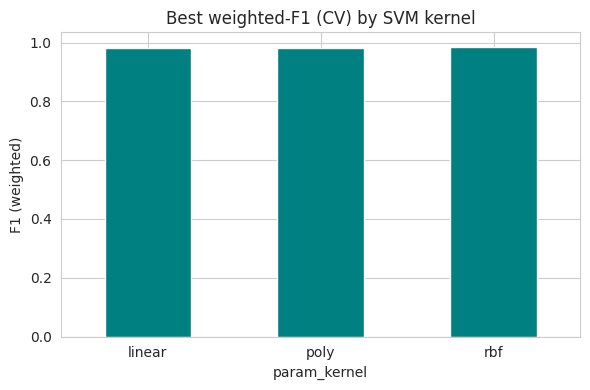

In [8]:
# Inspect how each kernel performed on average, for the report/write-up
cv_results = pd.DataFrame(svm_grid.cv_results_)
kernel_summary = cv_results.groupby(cv_results["param_kernel"])["mean_test_score"].agg(["mean", "max"])
print(kernel_summary)

kernel_summary["max"].plot(kind="bar", figsize=(6, 4), color="teal")
plt.title("Best weighted-F1 (CV) by SVM kernel")
plt.ylabel("F1 (weighted)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [9]:
# Evaluate the tuned SVM on the validation set
svm_val_pred = svm_best.predict(X_val_scaled)

svm_metrics = {
    "accuracy": accuracy_score(y_val, svm_val_pred),
    "precision": precision_score(y_val, svm_val_pred, average="weighted"),
    "recall": recall_score(y_val, svm_val_pred, average="weighted"),
    "f1": f1_score(y_val, svm_val_pred, average="weighted"),
}
print("SVM — validation metrics:")
for k, v in svm_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nClassification report:\n", classification_report(y_val, svm_val_pred, target_names=label_encoder.classes_))


SVM — validation metrics:
  accuracy: 0.9905
  precision: 0.9905
  recall: 0.9905
  f1: 0.9905

Classification report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.97      0.98      0.97       257
          STANDING       0.98      0.97      0.97       275
           WALKING       1.00      1.00      1.00       245
WALKING_DOWNSTAIRS       1.00      1.00      1.00       197
  WALKING_UPSTAIRS       1.00      1.00      1.00       215

          accuracy                           0.99      1471
         macro avg       0.99      0.99      0.99      1471
      weighted avg       0.99      0.99      0.99      1471



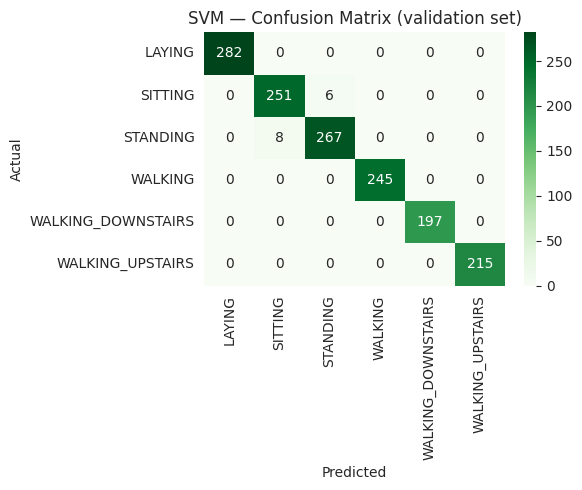

In [10]:
cm_svm = confusion_matrix(y_val, svm_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("SVM — Confusion Matrix (validation set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


                    precision    recall        f1
LAYING               1.000000  1.000000  1.000000
SITTING              0.969112  0.976654  0.972868
STANDING             0.978022  0.970909  0.974453
WALKING              1.000000  1.000000  1.000000
WALKING_DOWNSTAIRS   1.000000  1.000000  1.000000
WALKING_UPSTAIRS     1.000000  1.000000  1.000000


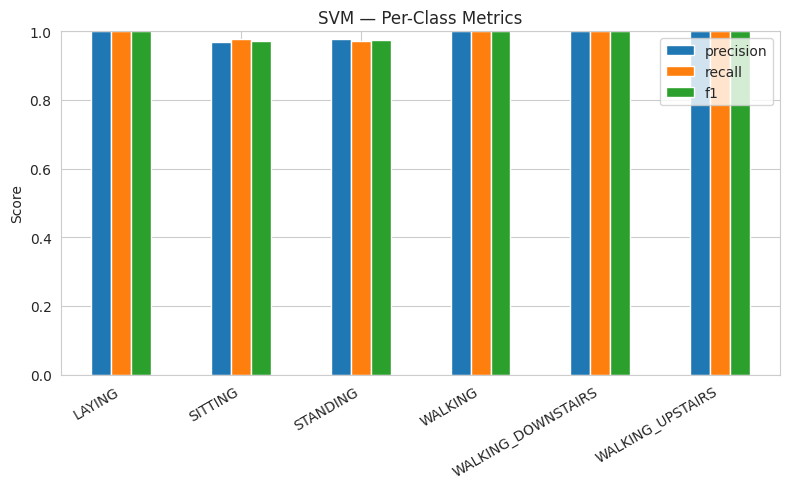

In [11]:
# Per-class metrics, useful for spotting which activities are hardest to tell apart
per_class = pd.DataFrame({
    "precision": precision_score(y_val, svm_val_pred, average=None),
    "recall": recall_score(y_val, svm_val_pred, average=None),
    "f1": f1_score(y_val, svm_val_pred, average=None),
}, index=label_encoder.classes_)
print(per_class)

per_class.plot(kind="bar", figsize=(8, 5), ylim=(0, 1))
plt.title("SVM — Per-Class Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [12]:
# Refit the best SVM on the full training set
X_full_scaled = scaler.fit_transform(X)
X_kaggle_test_scaled_full = scaler.transform(X_kaggle_test)

svm_best.fit(X_full_scaled, y)
test_preds_encoded = svm_best.predict(X_kaggle_test_scaled_full)
test_preds = label_encoder.inverse_transform(test_preds_encoded)

submission = sample_sub.copy()

# Fill in whichever column in sample_submission holds the predicted label
label_col_in_sub = next((c for c in submission.columns if c != id_col), submission.columns[-1])
submission[label_col_in_sub] = test_preds

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
submission.head()


Saved submission.csv


,id,Activity
0,1,STANDING
1,2,STANDING
2,3,STANDING
3,4,STANDING
4,5,STANDING
